# Week 2: Estimation (Individual)

In Week 1, you explored the system and developed a shared simulation framework.  
In Week 2, you will begin working individually to extract useful structure from the observed data.

## Objective

The internal state of the system is not directly observable. Your task is to design an approach that uses the available observations (and inputs) to construct a useful representation of the system.

There is **no single correct method**. You are expected to logically propose, clearly justify, and meaningfully evaluate your own approach.

## What does “estimation” mean here?

Depending on your design choices, your method need to aim to:

- identify patterns or structure in the observations,
- predict future observations,
- reconstruct hidden variables,
- compress the data into a lower-dimensional representation,
- extract features that can later be used for control.

## Tasks

You should:

1. **Define your objective**  
   Decide what you are trying to estimate and why it is useful.

2. **Design an approach**  
   Propose one or more methods based on your understanding of the system. Where possible, explore different approaches rather than relying on a single method, and compare their performance. Select the approach you consider most effective and justify your choice. Clearly state any assumptions you make.

3. **Implement your method**  
   Build on the Week 1 codebase. Test it on at least one simulation from Week 1. Your implementation does not need to be perfect, but it should be coherent and testable.

4. **Evaluate performance**  
   Use plots and quantitative measures to assess your method. Consider:
   - sensitivity to noise,
   - stability over time,
   - generalisation across different input patterns.

5. **Reflect on limitations**  
   Identify what your method does not capture and what could be improved.

## Guidance
- You may use both observations \(y(t)\) and inputs \(u(t)\). But inputs are not 100% reliable.
- You may use past data (history) if helpful.
- Simpler methods are acceptable if they are clearly justified and well analysed.
- A partially successful but well-explained approach is better than a complex but poorly understood one.

## Week 2 deliverable
**Deliverable:** Interim Report + code.
**Marks:** 20 individual marks.
**Due:** Friday 29 May at 9:00am BST. 

## Testing and evaluating your interface
On **Friday 29 May between 11am and 1pm**, the demonstrator will test your estimator to ensure that your interface meets the required specifications.  

This session is **compulsory** and important for your understanding and progression to the next stage of the project.

## Interim report guidance
Your interim report should be concise and focused, approximately **4 pages** in length, and must not exceed **5 pages total**, including figures and any appendix material.

The report should include:

- A brief description of the system and the simulations you have run,
- A summary of your Week 1 exploration,
- A clear description of your estimation approach,
- Initial results, with figures, demonstrating depth of analysis rather than broad but superficial coverage,
- A discussion of limitations and planned next steps.

The goal of the interim report is to demonstrate your understanding so far and to receive feedback ahead of the final stage.

## Connection to later work
Your estimation approach will form the basis for your control strategy in Week 3.  
Think ahead about how your representation could be used to influence the system.

## Estimation interface

To make testing and evaluation consistent across students, all estimation methods must follow the interface below.

You are free to implement any estimation strategy internally, provided that your function:
- accepts observations as input,
- returns estimated latent states and estimated inputs,
- and preserves the required function signature.

### Important:
- Do not change the function signature of `estimate_latent_and_input`. The demonstrator will call this function to evaluate your solution during the Week 2 evaluation session.
- You may implement any logic inside the function, but it must return:
   1. estimated latent states with shape (Timepoints, LatentDim)
   2. estimated inputs with shape (Timepoints, InputDim)
- If your method uses additional hyperparameters, use partial functions or wrapper functions to fix them before submission. You will not have the opportunity to adjust hyperparameters during the test. Automatic parameter tuning is welcome.


In [ ]:
"""Single-trial blind estimation of latent states and inputs for a
linear-Gaussian state-space model.

Interface (do not change):
    estimate_latent_and_input(observation, LatentDim, InputDim)
        observation : (T, p) array of observations for ONE trial
        returns     : (x_hat, u_hat) of shapes (T, LatentDim), (T, InputDim)

Model
-----
    x_{t+1} = A x_t + B u_t + w_t,   w ~ N(0, Q)         (state dynamics)
    y_t     = C x_t + D u_t + v_t,   v ~ N(0, R)         (observation map)

The input u_t is unobserved. We treat it as a latent process with a driftless
random-walk (AR(1)) prior u_{t+1} = u_t + eta_t, eta ~ N(0, Sigma_u), and fold
it into an augmented state z_t = [x_t; u_t]:

    z_{t+1} = [[A, B], [0, I]] z_t + w_aug,
    y_t     = [C, D] z_t + v_t,
    Q_aug   = blkdiag(Q, Sigma_u),  R_aug = R.

The augmented system is an ordinary unsupervised linear-Gaussian model driven
only by noise, fitted by constrained EM (Kalman filter + RTS smoother E-step,
closed-form M-step on the free blocks A, B, C, D, Q, R only -- the input block
[0, I] and Sigma_u are held fixed; see report Section 5.3 for the role of this
constraint in identifiability).

Two stages per call:
  1. Identify (A, B, C, D, Q, R) from the supplied observation by EM.
     Initialisation uses l4b PCA (top-n components -> C) and l4b Autocorrelation
     (lag-1 AC of PCA scores -> diagonal A). Subsequent restarts perturb this
     warm start; the highest-likelihood fit is retained.
  2. Recover (x_hat, u_hat) by augmented RTS smoothing under the identified
     parameters; the leading n coordinates of z give x, the trailing m give u.

Limitations (see report Section 5.3, 5.4):
  * The AR(1) input prior penalises rapid variation, biasing the input estimate
    toward smooth signals.
  * The augmented state is identified up to a similarity transform; we report
    aligned R^2 which absorbs the residual gauge.

All hyperparameters are frozen in the constants below. Nothing is tuned at
evaluation time; the input-prior scale is set deterministically from the data.
"""

from typing import Tuple

import numpy as np

# ---- frozen hyperparameters ----------------------------------------------- #
_N_ITER = 100          # EM iterations per restart (cap; convergence is earlier)
_N_RESTARTS = 4        # restarts from perturbed warm start; best likelihood kept
_LL_TOL = 1e-4         # relative log-likelihood convergence tolerance
_JITTER = 1e-6         # diagonal regularisation on covariance updates

def _warm_start(Y, n):
    '''Compute the warm-start initialisation for EM from l4b tools.
    
    Parameters
    ----------
    Y : (T, p) array of observations for ONE trial
    n : latent state dimension
    
    Returns
    -------
    C_init : (p, n) initial observation map
    A_init : (n, n) initial state transition matrix (diagonal)
    '''
    # from l4b.dataset import Dataset
    # from l4b.stats.pca import PCA
    # from l4b.stats.autocorrelation import Autocorrelation

    # Y_centered = Y - Y.mean(0, keepdims=True)  # zero-centre for PCA
    # ds = Dataset(observations=Y_centered[np.newaxis])
    # pca = PCA(ds, n_components=n)
    # C_init = pca.result.components.T
    # scores = pca.result.scores
    # X = scores[:-1]
    # Yt = scores[1:]
    # A_init = np.linalg.lstsq(X, Yt, rcond=None)[0].T 



    #In case the imports don't work : 
    T, p = Y.shape
    mu = Y.mean(0, keepdims=True)
    _, _, Vt = np.linalg.svd(Y - mu, full_matrices=False)
    C_init = Vt[:n].T
    Xpx = (Y - mu) @ C_init                                   # crude state proxy
    A_init = np.linalg.lstsq(Xpx[:-1], Xpx[1:], rcond=None)[0].T

    return C_init, A_init

def _kalman_filter(Y, A, C, Q, R, z0, P0):
    '''Kalman filter for the augmented (no-external-input) LG-SSM.
    
    Parameters
    ----------
    Y : (T, p) array of observations for ONE trial
    A : (n, n) state transition matrix
    C : (p, n) observation matrix
    Q : (n, n) process noise covariance
    R : (p, p) observation noise covariance
    z0 : (n,) initial state mean
    P0 : (n, n) initial state covariance
    
    Returns
    -------
    xf : (T, n) filtered state means
    Pf : (T, n, n) filtered state covariances
    xp : (T, n) predicted state means
    Pp : (T, n, n) predicted state covariances
    ll : marginal log-likelihood
    '''
    T, p = Y.shape
    na = A.shape[0]
    xf = np.zeros((T, na));    Pf = np.zeros((T, na, na))   # filtered (post-update)
    xp = np.zeros((T, na));    Pp = np.zeros((T, na, na))   # predicted (pre-update)
    I = np.eye(na)
    x_prev, P_prev = z0.copy(), P0.copy()
    ll = 0.0
    for t in range(T):
        # ----- predict ------------------------------------------------------ #
        if t == 0:
            x_pred, P_pred = z0.copy(), P0.copy()        # prior at t=0
        else:
            x_pred = A @ x_prev
            P_pred = A @ P_prev @ A.T + Q
        xp[t], Pp[t] = x_pred, P_pred

        # ----- update (innovation form) ------------------------------------- #
        S = C @ P_pred @ C.T + R                          # innovation covariance
        e = Y[t] - C @ x_pred                             # innovation
        K = np.linalg.solve(S, C @ P_pred).T              # Kalman gain via solve
        x_filt = x_pred + K @ e
        P_filt = (I - K @ C) @ P_pred
        P_filt = 0.5 * (P_filt + P_filt.T)                # symmetrise (numerics)
        xf[t], Pf[t] = x_filt, P_filt
        x_prev, P_prev = x_filt, P_filt

        # ----- accumulate marginal log-likelihood --------------------------- #
        _, logdet = np.linalg.slogdet(S)
        ll += -0.5 * (logdet + e @ np.linalg.solve(S, e) + p * np.log(2 * np.pi))
    return xf, Pf, xp, Pp, ll

def _rts_smoother(A, xf, Pf, xp, Pp):
    T, na = xf.shape
    xs = xf.copy(); Ps = Pf.copy()
    Plag = np.zeros((T, na, na))                          # Plag[t] = Cov(z_t, z_{t-1})
    for t in range(T - 2, -1, -1):
        # smoother gain (the analogue of the Kalman gain, running backwards)
        J = np.linalg.solve(Pp[t + 1], A @ Pf[t]).T       # = Pf[t] A^T Pp[t+1]^{-1}
        xs[t] = xf[t] + J @ (xs[t + 1] - xp[t + 1])
        Ps[t] = Pf[t] + J @ (Ps[t + 1] - Pp[t + 1]) @ J.T
        Plag[t + 1] = J @ Ps[t + 1]
    return xs, Ps, Plag


def _assemble(A, B, C, D, Q, R, F, Sigma_u):
    n, m = A.shape[0], B.shape[1]
    A_aug = np.block([[A, B], [np.zeros((m, n)), F]])     # [[A, B], [0, F]]
    C_aug = np.hstack([C, D])                             # [C, D]
    Q_aug = np.block([[Q, np.zeros((n, m))],
                      [np.zeros((m, n)), Sigma_u]])       # blkdiag(Q, Sigma_u)
    return A_aug, C_aug, Q_aug, R


def _fit_once(Y, n, m, F, Sigma_u, seed, C_init, A_init):
    T, p = Y.shape
    na = n + m
    rng = np.random.default_rng(seed)
    perturb = 0.05 * seed                                  # 0 for seed 0

    # ----- initialise ------------------------------------------------------- #
    C = C_init + perturb * rng.standard_normal((p, n))
    A = A_init + perturb * rng.standard_normal((n, n))
    D = 0.1 * rng.standard_normal((p, m))
    B = 0.1 * rng.standard_normal((n, m))
    Q = 0.1 * np.eye(n); R = 0.1 * np.eye(p)

    # diffuse prior on the input block of z0 (we know nothing about u_0)
    z0 = np.zeros(na); P0 = np.eye(na); P0[n:, n:] = Sigma_u * 10.0

    prev = -np.inf
    for _ in range(_N_ITER):
        # ----- E-step ------------------------------------------------------- #
        A_aug, C_aug, Q_aug, R_aug = _assemble(A, B, C, D, Q, R, F, Sigma_u)
        xf, Pf, xp, Pp, ll = _kalman_filter(Y, A_aug, C_aug, Q_aug, R_aug, z0, P0)
        xs, Ps, Plag = _rts_smoother(A_aug, xf, Pf, xp, Pp)

        # ----- accumulate sufficient statistics ----------------------------- #
        Szz = np.zeros((na, na)); Syz = np.zeros((p, na)); Syy = np.zeros((p, p))
        S11 = np.zeros((na, na)); S00 = np.zeros((na, na)); S10 = np.zeros((na, na))
        for t in range(T):
            Ezz = Ps[t] + np.outer(xs[t], xs[t])           # E[z_t z_t^T | Y]
            Szz += Ezz
            Syz += np.outer(Y[t], xs[t])
            Syy += np.outer(Y[t], Y[t])
            if t >= 1:
                S11 += Ezz
                S00 += Ps[t - 1] + np.outer(xs[t - 1], xs[t - 1])
                S10 += Plag[t] + np.outer(xs[t], xs[t - 1])
        Ndyn = T - 1

        # ----- M-step: regression updates for free blocks ------------------- #
        AB = np.linalg.solve(S00, S10.T).T
        A, B = AB[:n, :n], AB[:n, n:]

        CD = np.linalg.solve(Szz, Syz.T).T
        C, D = CD[:, :n], CD[:, n:]

        AB_top = np.hstack([A, B])
        Q = (S11[:n, :n] - AB_top @ S10[:n].T) / Ndyn
        Q = 0.5 * (Q + Q.T) + _JITTER * np.eye(n)

        R = (Syy - CD @ Syz.T) / T
        R = 0.5 * (R + R.T) + _JITTER * np.eye(p)

        if abs(ll - prev) < _LL_TOL * max(1.0, abs(prev)):
            break
        prev = ll
    return (A, B, C, D, Q, R), prev


def _identify(Y, n, m, F, Sigma_u):
    C_init, A_init = _warm_start(Y, n)
    best, best_ll = None, -np.inf
    for s in range(_N_RESTARTS):
        params, ll = _fit_once(Y, n, m, F, Sigma_u, seed=s,
                               C_init=C_init, A_init=A_init)
        if ll > best_ll:
            best, best_ll = params, ll
    return best


def _smooth(Y, params, n, m, F, Sigma_u):
    A, B, C, D, Q, R = params
    A_aug, C_aug, Q_aug, R_aug = _assemble(A, B, C, D, Q, R, F, Sigma_u)
    z0 = np.zeros(n + m); P0 = np.eye(n + m); P0[n:, n:] = Sigma_u * 10.0
    xf, Pf, xp, Pp, _ = _kalman_filter(Y, A_aug, C_aug, Q_aug, R_aug, z0, P0)
    zs, _, _ = _rts_smoother(A_aug, xf, Pf, xp, Pp)
    return zs[:, :n], zs[:, n:]


def estimate_latent_and_input(
    observation: np.ndarray, LatentDim: int, InputDim: int
) -> Tuple[np.ndarray, np.ndarray]:
    Y = np.asarray(observation, dtype=float)
    if Y.ndim != 2:
        raise ValueError(f"expected observation of shape (T, p); got {Y.shape}")
    T, p = Y.shape
    n, m = int(LatentDim), int(InputDim)

    F = np.eye(m)
    scale = float(np.var(np.diff(Y, axis=0))) if T > 1 else 1.0
    Sigma_u = np.eye(m) * max(scale, _JITTER)

    params = _identify(Y, n, m, F, Sigma_u)
    x_hat, u_hat = _smooth(Y, params, n, m, F, Sigma_u)

    assert x_hat.shape == (T, n) and u_hat.shape == (T, m)
    return x_hat, u_hat


(array([[ 9.30758266e-01, -6.29174527e-01, -3.01823434e-02,
         1.23123705e-01,  2.46572672e-01,  4.97589318e-03,
         2.46371093e-01, -2.03963156e-01, -2.30577001e-01,
         9.13760658e-03],
       [ 3.53931816e-02,  4.39972996e-01,  1.34833301e-01,
         4.92459118e-01, -3.97325228e-01,  8.89626811e-02,
        -3.09949961e-01, -4.86068919e-01, -1.72683642e-01,
         5.43150155e-01],
       [ 1.41332284e-02,  2.40037307e-01, -2.97007746e-01,
         2.08333877e-01,  6.33468252e-02, -3.27876034e-02,
        -1.84798959e-01, -4.38762328e-01,  1.17445743e-01,
         9.08771849e-02],
       [ 5.69475520e-03,  1.21268731e-01, -1.27104521e-01,
        -3.67400537e-01, -5.00360564e-01, -3.36812028e-02,
         2.81929492e-01, -2.20447503e-01, -3.06359035e-01,
         2.79541013e-01],
       [ 2.06223873e-03,  1.97381416e-01,  2.80152067e-02,
         1.52559645e-01, -4.69672542e-01, -3.03174425e-01,
        -7.61347091e-02,  2.97494608e-01, -1.87206893e-01,
        -3

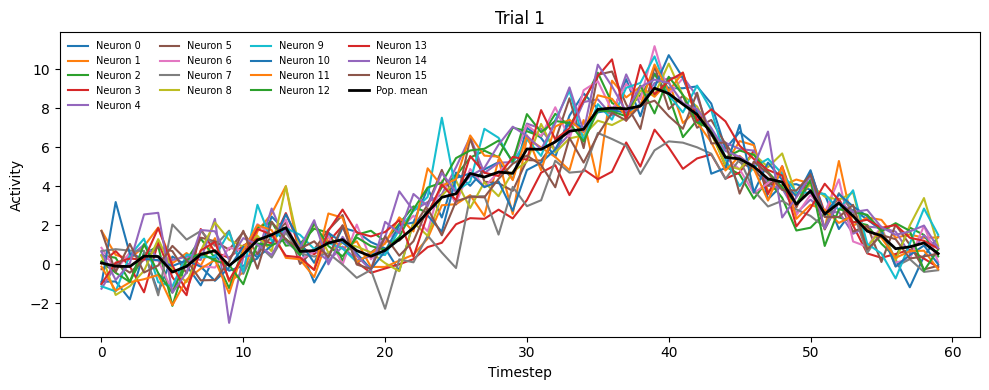

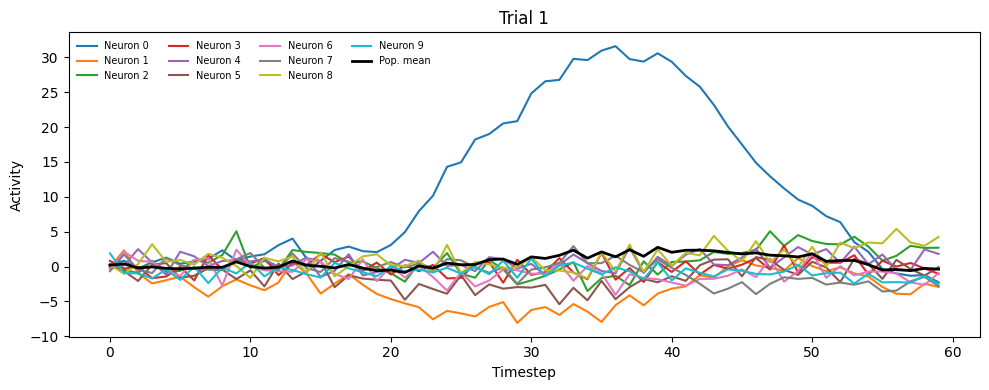

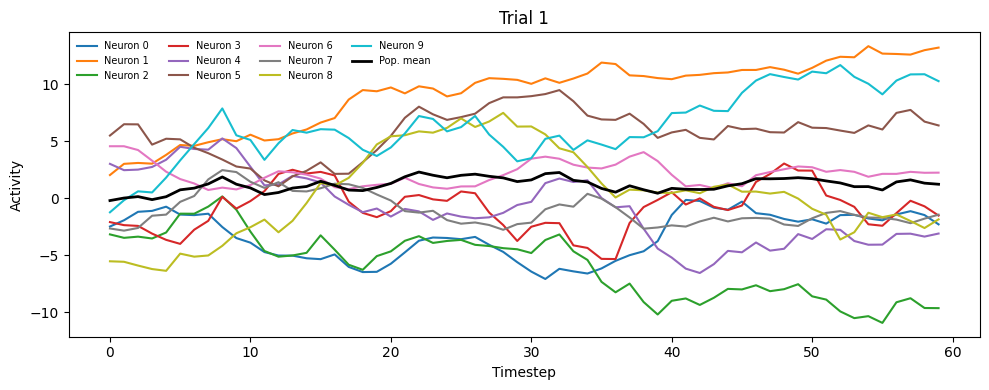

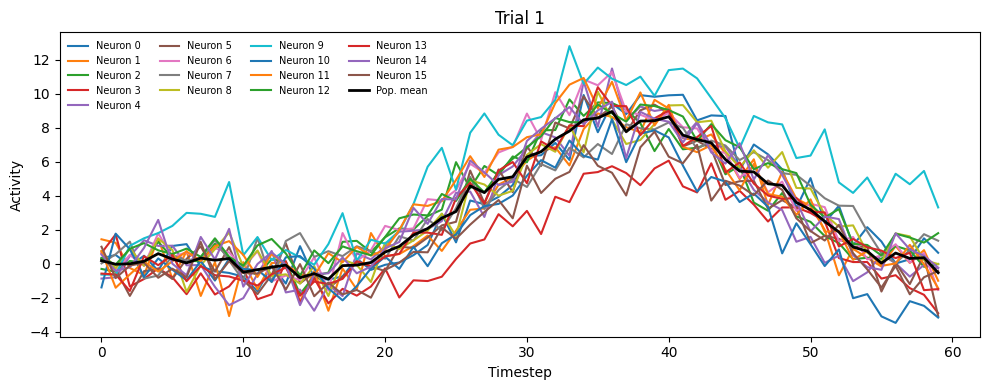

In [39]:
from l4b.illustrator import Illustrator

LatentDim, InputDim = 10, 10

def evaluate_model(
    observation: np.ndarray, LatentDim: int, InputDim: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    Y = np.asarray(observation, dtype=float)
    if Y.ndim != 2:
        raise ValueError(f"expected observation of shape (T, p); got {Y.shape}")
    T, p = Y.shape
    n, m = int(LatentDim), int(InputDim)

    F = np.eye(m)
    scale = float(np.var(np.diff(Y, axis=0))) if T > 1 else 1.0
    Sigma_u = np.eye(m) * max(scale, _JITTER)

    params = _identify(Y, n, m, F, Sigma_u)
    x_hat, u_hat = _smooth(Y, params, n, m, F, Sigma_u)

    assert x_hat.shape == (T, n) and u_hat.shape == (T, m)
    return x_hat, u_hat, params
# illustrator.plot_trials(estimated_inputs)

estimated_latent_states, estimated_inputs, model_params = evaluate_model(
    data[0], LatentDim, InputDim)


observations = Illustrator(np.array([data[0]])).plot_trials()
latent_states = Illustrator(np.array([estimated_latent_states])).plot_trials()
inputs = Illustrator(np.array([estimated_inputs])).plot_trials()
print(model_params)

from l4b import Simulator
from l4b.simulation import ControllabilityGramian

test = Simulator(
    model=(
        {
            "state_dim": estimated_latent_states.shape[1],
            "input_dim": estimated_inputs.shape[1],
            "obs_dim": 16,

            "A": model_params[0],
                
            "B": model_params[1],

            "C": model_params[2],

            "D": model_params[3],

            "Q": model_params[4],
        
            "R": model_params[5],
        }
    )
)

states, observations = test.run(
    initial_state=estimated_latent_states[0], control_inputs=estimated_inputs, time_steps=60, trials=1
)

fig = Illustrator(observations).plot_trials()